# Cuaderno 9: Aproximaciones de primer orden

**Departamento de Ciencias Físicas y Exactas / FIDCA**

<span style="color: var(--icesi-blue);">Colaborador: Hernan G. Triana</span>

<!--
Copyright © Angela Villota y Aníbal Sosa.

El contenido textual está licenciado bajo Creative Commons
Attribution-NonCommercial 4.0 International (CC BY-NC 4.0).

El código y la lógica de los notebooks están licenciados bajo
PolyForm Noncommercial License 1.0.0.

Consulte el archivo LICENSE del repositorio para conocer los términos completos.
-->

#Mejor aproximación Afín

Una función $f: \mathbb{R} → \mathbb{R}$ se llama función afín si existen constantes $m$ y $b$ distintas de cero, tales que


  $$f(x)=mx+b$$
  

  para todo $x$ en el dominio de $f$.
  

  Graficamente estas funciones corresponden a lineas rectas que no pasan por el origen, como se muestra en la siguiente figura.

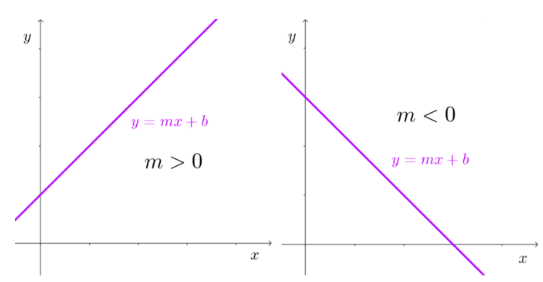

El problema de encontrar la recta tangente a una función $f$ en un punto $(x_0, y_0)$ permite plantear el problema de encontrar la función afín que mejor aproxima a $f$ en puntos cercanos a $x_0$. Veamos,

**Figura 1**

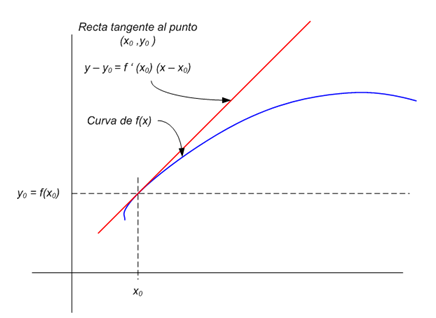

De la gráfica es claro que podemos aproximar $f(x)$ mediante la función afín $T(x)$



$$T(x)\approx f'(x_0)(x-x_0)+f(x_0)$$


en puntos cercanos a $x_0$.


#Ejemplo

Hallar la mejor aproximación afín a $f(x)=x^2+2$ cerca de $x_0=1$


#Solución

En   $x_0=1$    se tiene    $f(x_0)=1^2+2=3$   → $f(1)=3$


Ahora   $f'(x)=2x$,   entonces   $f'(x_0)=2(1)=2$    →  $f'(1)=2$


La mejor aproximación afín a $f(x)=x^2+2$   cerca de   $x_0=1$   es,


$$T(x)\approx f'(x_0)(x-x_0)+f(x_0)$$


$$T(x)\approx 2(x-1)+3$$


$$T(x)\approx 2x+1$$


Como puede verse en la siguiente gráfica.
 

In [ ]:
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/jvquzjpx",
  width="800px",
  height="600px"
  )

IP.display_html(iframe)

#Método de Newton

Suponga que se requiere aproximar la solución de la ecuación


$$f(x)=0$$


para alguna función dada $y=f(x)$. Esto corresponde a encontrar los puntos en los que la función corta el eje $x$.


Para empezar, trazamos la gráfica de $f(x)$ y escogemos un punto $x_0$ cercano al corte de $f(x)$ con el eje $x$.



**Figura 2**

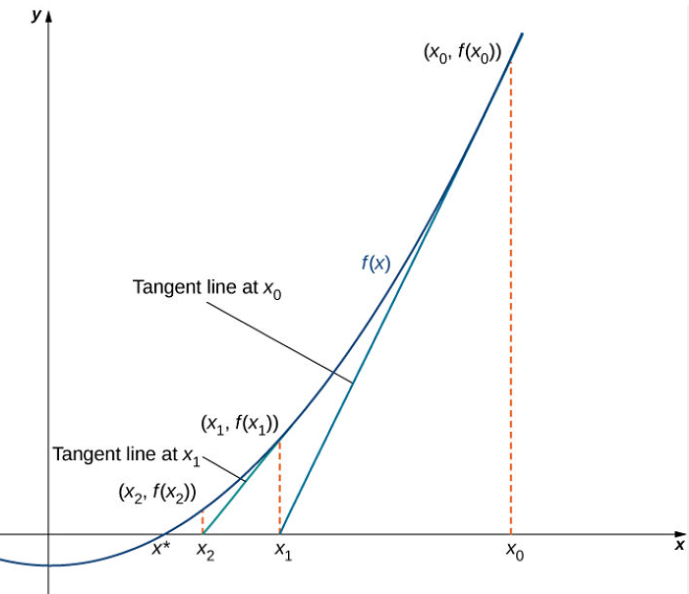

A continuación se aproxima $f(x)$ mediante la mejor aproximación afín cerca de $x_0$,


$$T(x)\approx f'(x_0)(x-x_0)+f(x_0)$$


Ahora se iguala $T(x)$ a cero para obtener $x_1$, el cual esta mas cerca del cero de $f(x)$,


$$f'(x_0)(x_1-x_0)+f(x_0)=0$$


$$f'(x_0)(x_1-x_0)=-f(x_0)$$


$$x_1-x_0 =- \frac{f(x_0)}{f'(x_0)}$$


$$x_1=x_0 - \frac{f(x_0)}{f'(x_0)}$$


Si se quiere seguir acercandose al cero, se aproxima $f(x)$ mediante la mejor aproximación afín cerca de $x_1$,


$$T(x_1)\approx f'(x_1)(x_2-x_1)+f(x_1)$$


Ahora se iguala $T(x_1)$ a cero para obtener $x_2$, el cual esta todavia mas cerca del cero de $f(x)$,


$$f'(x_1)(x_2-x_1)+f(x_1)=0$$


$$x_2=x_1 - \frac{f(x_1)}{f'(x_1)}$$


De esta forma se genera la sucesión de aproximaciones $x_0$, $x_1$,$x_2$,... hasta que se alcanza la precisión requerida. En general en cada iteración se tiene,


$$f'(x_n)(x_{n+1}-x_n)+f(x_n)=0$$


$$x_{n+1}=x_n - \frac{f(x_n)}{f'(x_n)}$$


Y el criterio para detener la iteración es que la diferencia entre dos aproximaciones sucesivas sea menor que una tolerancia $\epsilon$,


$$\|x_{n+1}-x_n\|<\epsilon$$


#Ejemplo

Aproximar los ceros de la funcion $f(x)=x^2-4x$ en el intervalo $(0,6)$


#Solución

Primero trazamos la grafica y notamos que dada la ubicación del cero podemos empezar a buscarlo mediante   $x_0=3$

In [ ]:
import IPython.display as IP

iframe = IP.IFrame(
  src="https://www.geogebra.org/classic/mhsjjxyc",
  width="800px",
  height="600px"
  )

IP.display_html(iframe)

# Método Númerico - Newton

En las siguientes lineas de codigo se contruye el algoritmo.

In [ ]:
def f(x):return x**2-4*x
def df(x):return 2*x-4



In [ ]:
x0=3
x1=x0-f(x0)/df(x0)
x1

4.5

In [ ]:
x0=4.5
x1=x0-f(x0)/df(x0)
x1

4.05

In [ ]:
x=3
x=x-f(x)/df(x)
x
x=x-f(x)/df(x)
x

4.05

In [ ]:
x=3
for _ in range(7):
  x=x-f(x)/df(x)
  print(x)



4.5
4.05
4.00060975609756
4.000000092922295
4.000000000000003
4.0
4.0


Código con tolerancia:


In [ ]:
# Método de Newton-Raphson

import numpy as np

# INGRESO
fx  = lambda x: x**2-4*x
dfx = lambda x: 2*x-4

x0 = 3
tolera = 0.001

# PROCEDIMIENTO
tabla = []
Etramo = abs(2*tolera)
xi = x0
while (Etramo>=tolera):
    xnuevo = xi - fx(xi)/dfx(xi)
    Etramo  = abs(xnuevo-xi)
    tabla.append([xi,xnuevo,Etramo])
    xi = xnuevo

# convierte la lista a un arreglo.
tabla = np.array(tabla)
n = len(tabla)

# SALIDA
print(['xi', 'xnuevo', 'tramo'])
np.set_printoptions(precision = 4)
print(tabla)
print('raiz en: ', xi)
print('con error de: ',Etramo)

['xi', 'xnuevo', 'tramo']
[[3.0000e+00 4.5000e+00 1.5000e+00]
 [4.5000e+00 4.0500e+00 4.5000e-01]
 [4.0500e+00 4.0006e+00 4.9390e-02]
 [4.0006e+00 4.0000e+00 6.0966e-04]]
raiz en:  4.000000092922295
con error de:  0.0006096631752656734


# Derivación numérica

La aproximación numérica de la derivada de una función en un punto se puede expresar de dos formas, por derecha (diferencias progresivas) y por izquierda (diferencias regresivas),

$$Df^+(x) = \frac{f(x+h)-f(x)}{h}$$

$$Df^-(x) = \frac{f(x-h)-f(x)}{-h}$$

sin embargo, la mejor aproximación es la que se obtiene del promedio de las dos aproximaciones anteriores, las diferencias centradas,

$$Df(x)=\frac{1}{2}(Df^{+}(x)+Df^{-}(x))=\frac{f(x+h)-f(x-h)}{2h}$$


A continuacion se dan los codigos para ejecutar estas aproximaciones

In [ ]:
def Deriv_derecha(f,x,h=0.0001):        # Definición de derivada haciendo uso de la aproximación por derecha.
  return (f(x+h)-f(x))/h

In [ ]:
def Deriv_izquierda(f,x,h=-0.0001):     # Definición de derivada haciendo uso de la aproximación por izquierda.
  return (f(x+h)-f(x))/h

In [ ]:
def Deriv_promedio(f,x):                 # derivada promedio Izquierda y Derecha
  return 0.5*(Deriv_derecha(f,x)+Deriv_izquierda(f,x))

Para la función $f(x)=x^4$, la aproximación de $f'(2)$

In [ ]:
Deriv_derecha(lambda x: x**4, 2)

32.002400080060056

In [ ]:
Deriv_izquierda(lambda x: x**4,2)


31.99760008000041

In [ ]:
Deriv_promedio(lambda x: x**4,2)


32.00000008003023

# Actividad

$(i)$ Utilice la función $f(x) = x^3 - 2x^2 - 5x + 6$ para Comparar el método de bisección con el método de Newton para aproximar los ceros de la función en $(-4,4)$ Presente el desarrollo de ambos métodos aqui. ¿Qué diferencia fundamental encuentra al aplicar ambos métodos a la misma función?.


$(ii)$ Utilice el método de Newton para aproximar la solución de la ecuación

$$x^{3}=cosx$$


$(iii)$ Demuestre que el método de Newton aplicado a la ecuación $x^{3}-a=0$ conduce a la fórmula

 $$x{_{(n+1)}}=\frac{1}{3}\left ( 2x{_{n}}+\frac{a}{{x_{n}}^2}\right )$$

   usada para aproximar la raíz cúbica de $a$. Utilice el método de Newton con esta expresión para aproximar el valor de $\sqrt[3]{7}$ con una presición de cinco decimales.
 

$(iv)$ Utilice las expresiones de derivación numérica para resolver aqui  mediante los coódigos, los siguientes problemas:

1. Usar diferencias progresivas para

$$
f(x)=x^2
$$

en $x=1$ con $h=0.1$.

2. Calcular la derivada de

$$
f(x)=e^x
$$

en $x=0$ usando diferencias regresivas con $h=0.05$.

3. Comparar diferencias progresivas y centradas para

$$
f(x)=\sin(x)
$$

en

$$
x=\frac{\pi}{4}
$$

con $h=0.1$.

4. Evaluar la segunda derivada de

$$
f(x)=x^3
$$

en $x=2$ mediante diferencias centradas con $h=0.2$.

5. Construir una tabla de diferencias hacia adelante para

$$
f(x)=\ln(x)
$$

en el intervalo

$$
[1,2]
$$

con $h=0.1$.

6. Aproximar la derivada de

$$
f(x)=\frac1x
$$

en $x=2$ mediante diferencias centradas.

7. Calcular la derivada de

$$
f(x)=\sqrt{x}
$$

entre $x=1$ y $x=2$ usando $h=0.1$.

8. Estimar la segunda derivada de

$$
f(x)=\sin(x)
$$

en $x=0$ mediante diferencias centradas.

9. Aplicar diferencias finitas a

$$
f(x)=x^4
$$

en $x=1$ para varios valores de $h$.